# Exercise 2

This notebook contains Assignment E2 which is on Loading and Visualizing Data from Flat Files (using AI).
This assignment is divided into 3 parts.

## Part 1 - Flat data and headers

In [1]:
import pandas as pd

# Load the tab-separated .dat file
df = pd.read_csv(
    r"C:\Users\Admin\Downloads\Samos_Core3\RNJKIA002_SAMOS-CORE3\E2\for_nitpicker.dat",
    sep='\t',
    header=None
)

# Add column names
df.columns = [
    "Date",
    "Time",
    "Depth",
    "Temperature",
    "Salinity"
]

# Save as CSV without index
df.to_csv(
    r"C:\Users\Admin\Downloads\Samos_Core3\RNJKIA002_SAMOS-CORE3\E2\Output.csv",
    index=False
)

# Display first 5 rows
df.head()

,Date,Time,Depth,Temperature,Salinity
0,11/29/2008,06:52,5,28.97,35.21
1,11/29/2008,06:52,6,28.98,35.21
2,11/29/2008,06:52,7,28.99,35.21
3,11/29/2008,06:52,8,28.96,35.21
4,11/29/2008,06:52,9,28.99,35.21


## Part 2 - Profiles

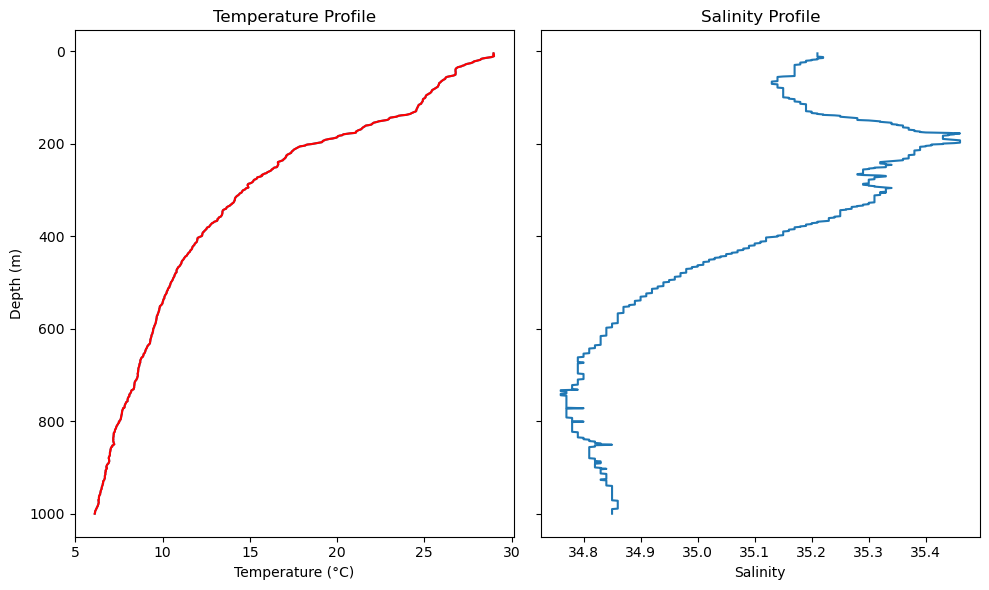

In [2]:
import matplotlib.pyplot as plt

# Create two panels sharing the y-axis
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 6))

# Temperature profile
ax[0].plot(df["Temperature"], df["Depth"])
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Temperature Profile")
ax[0].plot(df["Temperature"], df["Depth"], color='red')
# Salinity profile
ax[1].plot(df["Salinity"], df["Depth"])
ax[1].set_xlabel("Salinity")
ax[1].set_title("Salinity Profile")

# Make depth increase downward
ax[0].invert_yaxis()

# Improve spacing
plt.tight_layout()

# Show figure
plt.show()

## Part 3 - Time series

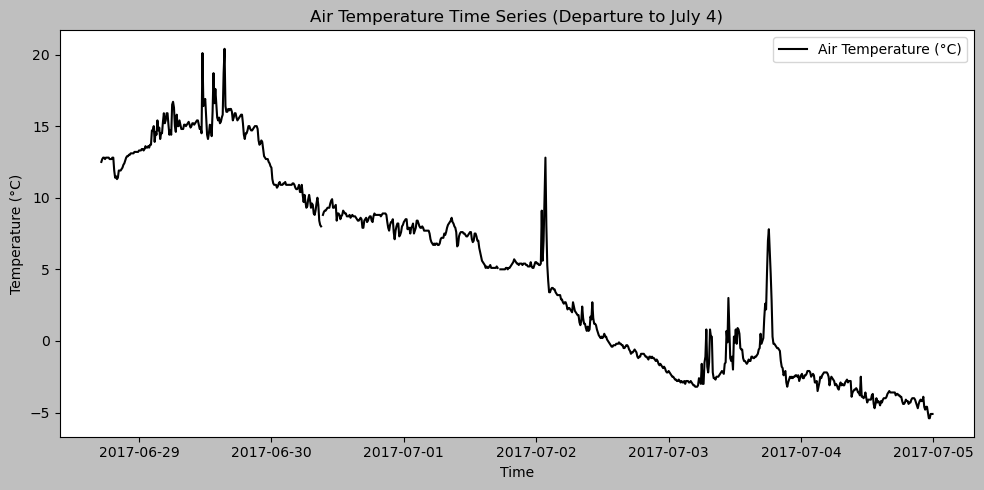

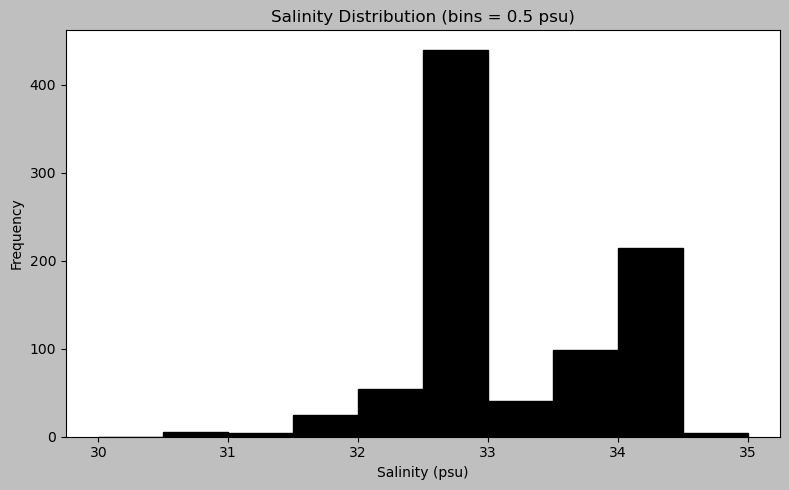

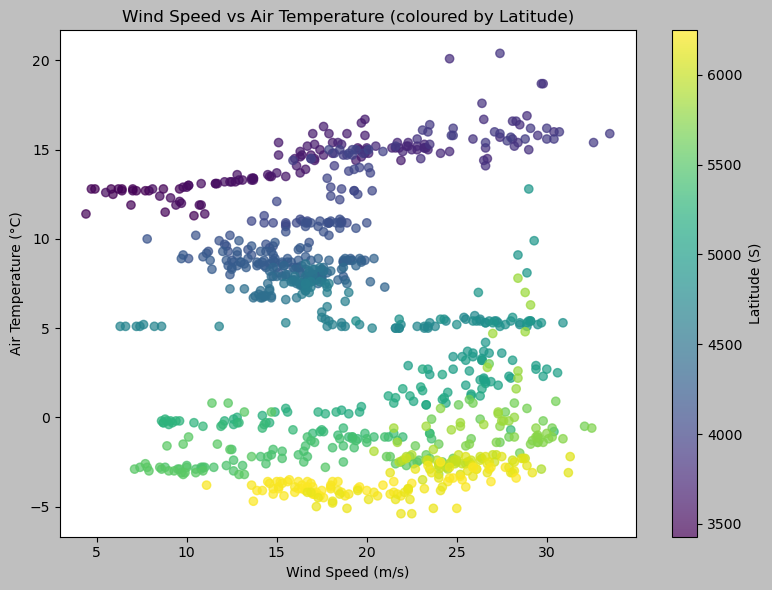

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv("SAA2_WC_2017_metocean_10min_avg.csv", parse_dates=["TIME_SERVER"], na_values=["NULL"])
df.set_index("TIME_SERVER", inplace=True)
selected = df.loc[:'2017-07-04']

# --- Temperature Time Series ---
plt.style.use('grayscale')
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(selected.index, selected["AIR_TEMPERATURE"], label="Air Temperature (°C)")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Air Temperature Time Series (Departure to July 4)")
ax.legend()
fig.tight_layout()
plt.show()   # <-- show instead of close

# --- Salinity Histogram ---
fig, ax = plt.subplots(figsize=(8,5))
bins = np.arange(30, 35.5, 0.5)
ax.hist(selected["TSG_SALINITY"].dropna(), bins=bins, edgecolor="black")
ax.set_xlabel("Salinity (psu)")
ax.set_ylabel("Frequency")
ax.set_title("Salinity Distribution (bins = 0.5 psu)")
fig.tight_layout()
plt.show()

# --- Scatter Plot Wind Speed vs Temperature ---
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(selected["WIND_SPEED_TRUE"], selected["AIR_TEMPERATURE"],
                c=selected["LATITUDE"], cmap="viridis", alpha=0.7)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Latitude (S)")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Air Temperature (°C)")
ax.set_title("Wind Speed vs Air Temperature (coloured by Latitude)")
fig.tight_layout()
plt.show()
